In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

# Create output directory
RESULT_DIR = "results"
os.makedirs(RESULT_DIR, exist_ok=True)

# CIFAR-10 class names
CLASS_NAMES = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

NUM_CLASSES = 10


IMAGE_SIZE = 96


TRAIN_SUBSET = 6000
VAL_SUBSET = 1500
TEST_SUBSET = 2000

# Training parameters
BATCH_SIZE = 64
LEARNING_RATE = 0.001
EPOCHS = 3

# Fine tuning
FINE_TUNE_EPOCHS = 2

print("=" * 70)
print("CS3807 - DEEP LEARNING LABORATORY")
print("EXPERIMENT 4 - TRANSFER LEARNING USING VGG16 (FAST MODE)")
print("=" * 70)

CS3807 - DEEP LEARNING LABORATORY
EXPERIMENT 4 - TRANSFER LEARNING USING VGG16 (FAST MODE)


In [3]:
print("\nLoading CIFAR-10 dataset...")

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("\nFull Dataset Information")
print("-" * 50)
print("Training images :", x_train.shape)
print("Training labels :", y_train.shape)
print("Testing images  :", x_test.shape)
print("Testing labels  :", y_test.shape)
print("Number of classes         :", NUM_CLASSES)


Loading CIFAR-10 dataset...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3296s 19us/step

Full Dataset Information
--------------------------------------------------
Training images : (50000, 32, 32, 3)
Training labels : (50000, 1)
Testing images  : (10000, 32, 32, 3)
Testing labels  : (10000, 1)
Number of classes         : 10


In [4]:
# ============================================================
# 3. NORMALIZE PIXEL VALUES
# ============================================================

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("\nPixel range after normalization:")
print("Minimum:", x_train.min())
print("Maximum:", x_train.max())


Pixel range after normalization:
Minimum: 0.0
Maximum: 1.0


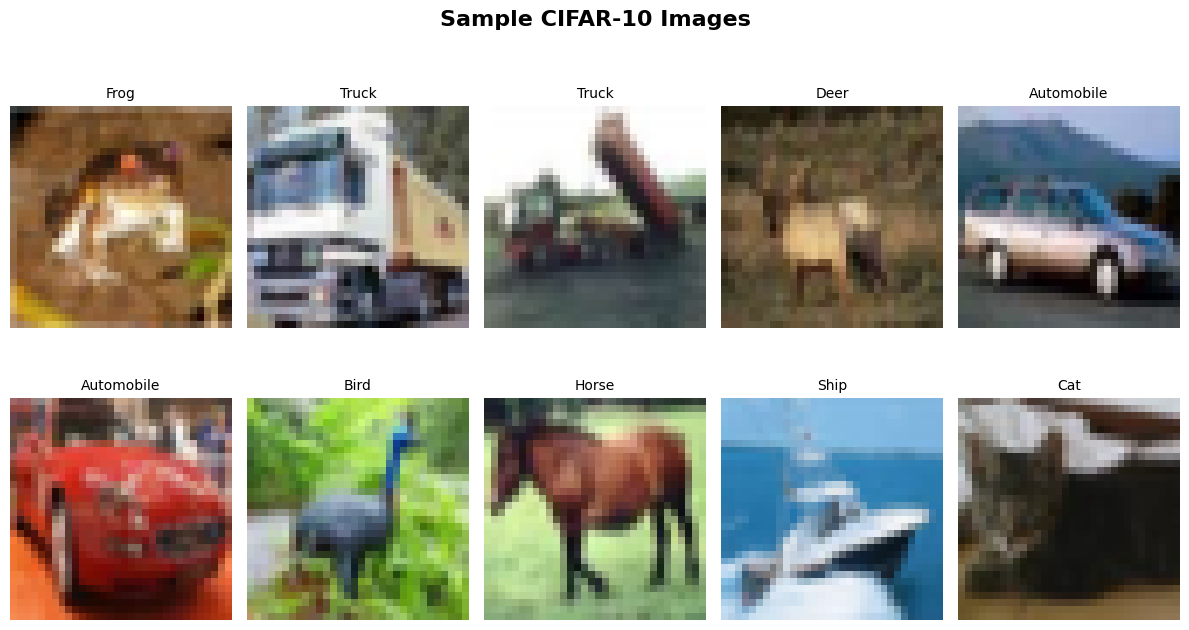


Saved: 01_sample_cifar10.eps


In [5]:
# ============================================================
# 4. DISPLAY 10 SAMPLE CIFAR-10 IMAGES
# ============================================================

plt.figure(figsize=(12, 7))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    label = CLASS_NAMES[int(y_train[i][0])]
    plt.title(label, fontsize=10)
    plt.axis("off")

plt.suptitle("Sample CIFAR-10 Images", fontsize=16, fontweight="bold")
plt.tight_layout()

plt.savefig(
    os.path.join(RESULT_DIR, "01_sample_cifar10.eps"),
    format="eps", dpi=600, bbox_inches="tight"
)
plt.show()
plt.close()

print("\nSaved: 01_sample_cifar10.eps")

In [6]:
# ============================================================
# 5. ONE-HOT ENCODE LABELS
# ============================================================

y_train_cat = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_test_cat = tf.keras.utils.to_categorical(y_test, NUM_CLASSES)

print("\nOne-hot encoded label shape:")
print("Training:", y_train_cat.shape)
print("Testing :", y_test_cat.shape)


One-hot encoded label shape:
Training: (50000, 10)
Testing : (10000, 10)


In [7]:
# ============================================================
# 6. CREATE VALIDATION SET + SUBSAMPLE
# ============================================================

# Use last 5000 training samples for validation (same as original),
# THEN subsample everything down to the fast-mode sizes.
x_val_full = x_train[-5000:]
y_val_full = y_train_cat[-5000:]

x_train_full = x_train[:-5000]
y_train_full = y_train_cat[:-5000]

# >>> CHANGED: subsample train/val/test with a fixed RNG for
# reproducibility, instead of using the full sets.
rng = np.random.RandomState(SEED)

train_idx = rng.choice(len(x_train_full), size=TRAIN_SUBSET, replace=False)
val_idx = rng.choice(len(x_val_full), size=VAL_SUBSET, replace=False)
test_idx = rng.choice(len(x_test), size=TEST_SUBSET, replace=False)

x_train_final = x_train_full[train_idx]
y_train_final = y_train_full[train_idx]

x_val = x_val_full[val_idx]
y_val = y_val_full[val_idx]

x_test_sub = x_test[test_idx]
y_test_sub = y_test[test_idx]
y_test_cat_sub = y_test_cat[test_idx]

print("\nDataset Split (subsampled for speed)")
print("-" * 50)
print("Training   :", x_train_final.shape)
print("Validation :", x_val.shape)
print("Testing    :", x_test_sub.shape)


Dataset Split (subsampled for speed)
--------------------------------------------------
Training   : (6000, 32, 32, 3)
Validation : (1500, 32, 32, 3)
Testing    : (2000, 32, 32, 3)


In [8]:
# ============================================================
# 7. DATA PREPROCESSING FOR VGG16
# ============================================================

def preprocess_dataset(images):
    images = tf.image.resize(images, (IMAGE_SIZE, IMAGE_SIZE))
    images = images * 255.0  # [0,1] -> [0,255]
    images = preprocess_input(images)  # VGG16 preprocessing
    return images


train_dataset = tf.data.Dataset.from_tensor_slices((x_train_final, y_train_final))
val_dataset = tf.data.Dataset.from_tensor_slices((x_val, y_val))
test_dataset = tf.data.Dataset.from_tensor_slices((x_test_sub, y_test_cat_sub))

train_dataset = train_dataset.map(
    lambda x, y: (preprocess_dataset(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)
val_dataset = val_dataset.map(
    lambda x, y: (preprocess_dataset(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)
test_dataset = test_dataset.map(
    lambda x, y: (preprocess_dataset(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

train_dataset = (
    train_dataset
    .cache()
    .shuffle(buffer_size=TRAIN_SUBSET, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
val_dataset = (
    val_dataset
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
test_dataset = (
    test_dataset
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)


In [9]:
# ============================================================
# 8. LOAD PRETRAINED VGG16
# ============================================================

print("\nLoading pretrained VGG16...")

base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)
)

print("VGG16 loaded successfully.")


Loading pretrained VGG16...
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
VGG16 loaded successfully.


In [10]:
# ============================================================
# 9. FREEZE CONVOLUTIONAL BASE
# ============================================================

base_model.trainable = False
print("\nVGG16 convolutional base frozen.")


VGG16 convolutional base frozen.


In [11]:
# ============================================================
# 10. BUILD TRANSFER LEARNING MODEL
# ============================================================

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu", name="dense_128"),
    layers.Dense(NUM_CLASSES, activation="softmax", name="output")
], name="VGG16_Transfer_Learning")

In [12]:
# ============================================================
# 11. COMPILE MODEL
# ============================================================

optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)

model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [13]:
# ============================================================
# 12. DISPLAY MODEL SUMMARY
# ============================================================

print("\nModel Summary")
print("=" * 70)
model.summary()


Model Summary


Model: "VGG16_Transfer_Learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 3, 3, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,781,642 (56.39 MB)

 Trainable params: 66,954 (261.54 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [14]:
# ============================================================
# 13. COUNT PARAMETERS
# ============================================================

total_params = model.count_params()
trainable_params = np.sum([np.prod(v.shape) for v in model.trainable_variables])
non_trainable_params = total_params - trainable_params

print("\nParameter Information")
print("-" * 50)
print("Total parameters      :", total_params)
print("Trainable parameters  :", trainable_params)
print("Non-trainable params  :", non_trainable_params)



Parameter Information
--------------------------------------------------
Total parameters      : 14781642
Trainable parameters  : 66954
Non-trainable params  : 14714688


In [15]:
# ============================================================
# 14. TRAIN TRANSFER LEARNING MODEL
# ============================================================

print("\n")
print("=" * 70)
print("TRAINING TRANSFER LEARNING MODEL")
print("=" * 70)

start_time = time.time()

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS
)

training_time = time.time() - start_time

print("\nInitial training completed.")
print("Training time: {:.2f} seconds".format(training_time))




TRAINING TRANSFER LEARNING MODEL
Epoch 1/3
94/94 ━━━━━━━━━━━━━━━━━━━━ 817s 9s/step - accuracy: 0.5980 - loss: 1.9140 - val_accuracy: 0.7067 - val_loss: 1.1183
Epoch 2/3
94/94 ━━━━━━━━━━━━━━━━━━━━ 815s 9s/step - accuracy: 0.7997 - loss: 0.6531 - val_accuracy: 0.7333 - val_loss: 0.9826
Epoch 3/3
94/94 ━━━━━━━━━━━━━━━━━━━━ 819s 9s/step - accuracy: 0.8732 - loss: 0.3910 - val_accuracy: 0.7487 - val_loss: 0.9277

Initial training completed.
Training time: 2450.75 seconds


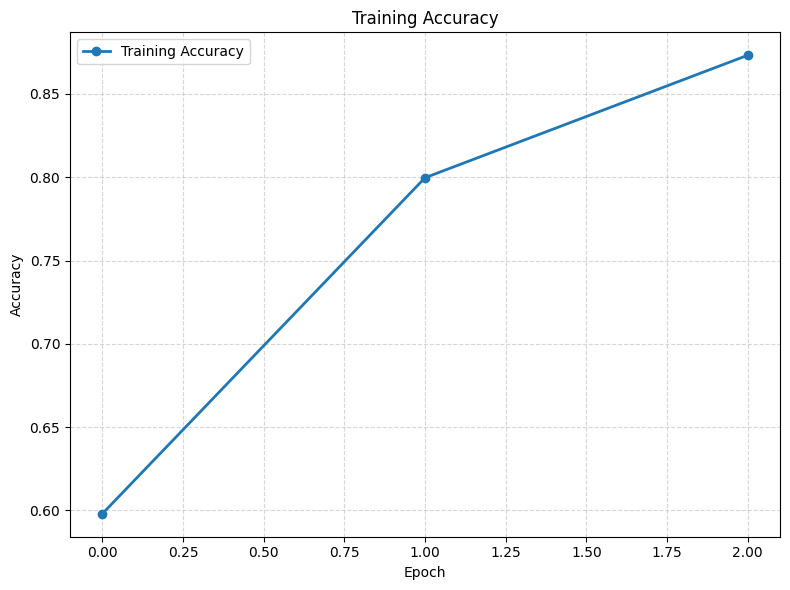

Saved: 02_training_accuracy.eps


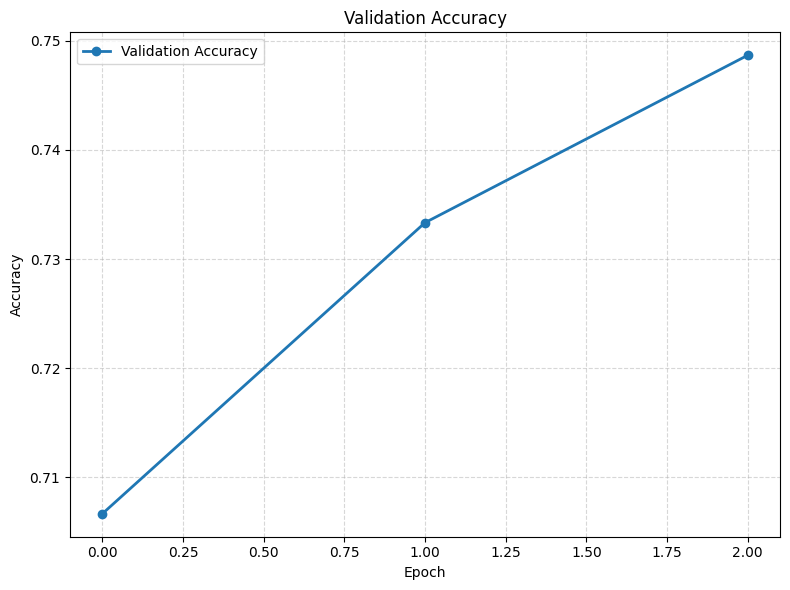

Saved: 03_validation_accuracy.eps


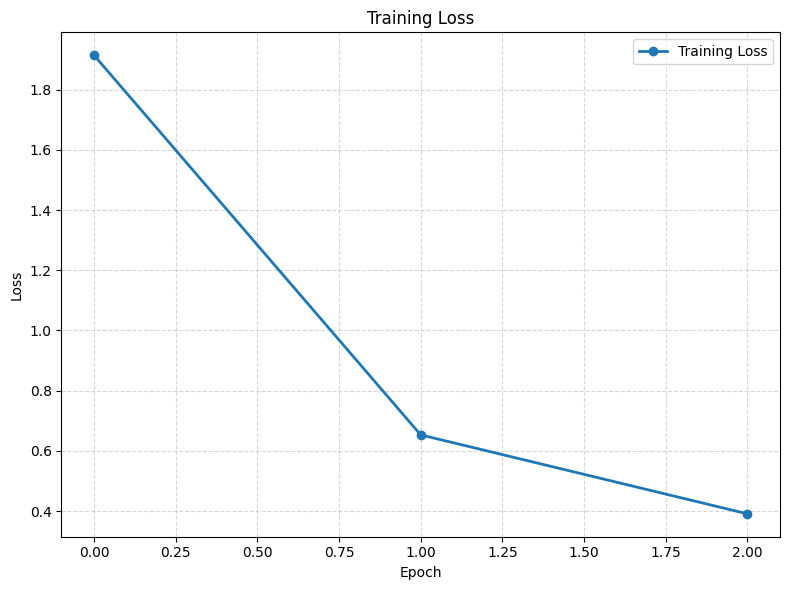

Saved: 04_training_loss.eps


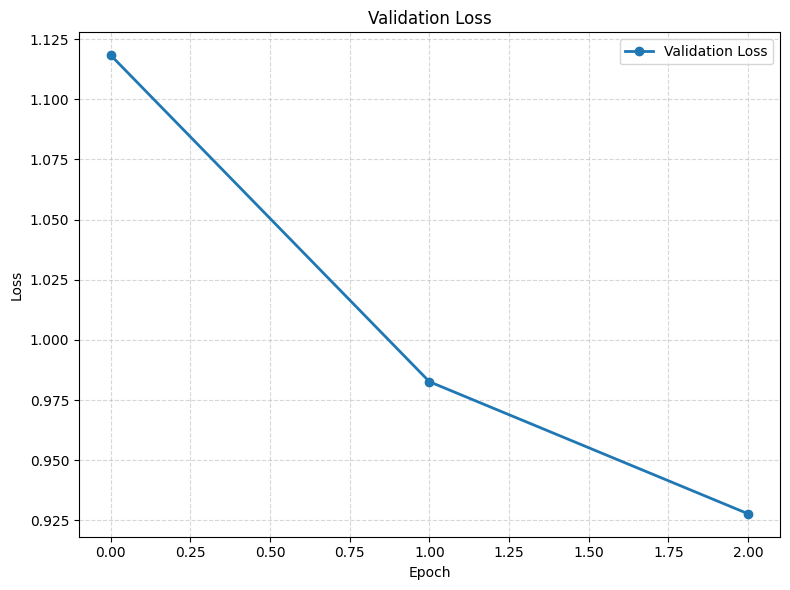

Saved: 05_validation_loss.eps


In [16]:
# ============================================================
# 15-18. PLOT TRAINING / VALIDATION ACCURACY & LOSS (initial)
# ============================================================

def plot_metric(values, ylabel, title, filename, marker_label):
    plt.figure(figsize=(8, 6))
    plt.plot(values, linewidth=2, marker="o", label=marker_label)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(RESULT_DIR, filename), format="eps", dpi=600, bbox_inches="tight")
    plt.show()
    plt.close()
    print("Saved:", filename)


plot_metric(history.history["accuracy"], "Accuracy", "Training Accuracy",
            "02_training_accuracy.eps", "Training Accuracy")
plot_metric(history.history["val_accuracy"], "Accuracy", "Validation Accuracy",
            "03_validation_accuracy.eps", "Validation Accuracy")
plot_metric(history.history["loss"], "Loss", "Training Loss",
            "04_training_loss.eps", "Training Loss")
plot_metric(history.history["val_loss"], "Loss", "Validation Loss",
            "05_validation_loss.eps", "Validation Loss")

In [17]:
# ============================================================
# 19. EVALUATE BEFORE FINE TUNING
# ============================================================

print("\n")
print("=" * 70)
print("EVALUATION BEFORE FINE TUNING")
print("=" * 70)

test_loss_before, test_acc_before = model.evaluate(test_dataset, verbose=1)
print("\nTesting Accuracy Before Fine Tuning:")
print("{:.4f}".format(test_acc_before))



EVALUATION BEFORE FINE TUNING
32/32 ━━━━━━━━━━━━━━━━━━━━ 215s 7s/step - accuracy: 0.7475 - loss: 0.9082

Testing Accuracy Before Fine Tuning:
0.7475


In [18]:
# ============================================================
# 20. FINE TUNING
# ============================================================

print("\n")
print("=" * 70)
print("FINE TUNING VGG16")
print("=" * 70)

base_model.trainable = True

for layer in base_model.layers:
    layer.trainable = False

for layer in base_model.layers:
    if layer.name.startswith("block5"):
        layer.trainable = True

trainable_params_finetune = np.sum([np.prod(v.shape) for v in model.trainable_variables])
print("\nTrainable parameters after fine tuning:", trainable_params_finetune)



FINE TUNING VGG16

Trainable parameters after fine tuning: 7146378


In [19]:
# ============================================================
# 21. RECOMPILE WITH SMALL LEARNING RATE
# ============================================================

fine_tune_optimizer = tf.keras.optimizers.Adam(learning_rate=0.00001)

model.compile(
    optimizer=fine_tune_optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [20]:
# ============================================================
# 22. FINE TUNE MODEL
# ============================================================

start_fine_tune = time.time()

fine_history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=FINE_TUNE_EPOCHS
)

fine_tuning_time = time.time() - start_fine_tune

print("\nFine tuning time: {:.2f} seconds".format(fine_tuning_time))


Epoch 1/2
94/94 ━━━━━━━━━━━━━━━━━━━━ 948s 10s/step - accuracy: 0.9247 - loss: 0.2388 - val_accuracy: 0.7640 - val_loss: 0.9316
Epoch 2/2
94/94 ━━━━━━━━━━━━━━━━━━━━ 1030s 11s/step - accuracy: 0.9798 - loss: 0.0875 - val_accuracy: 0.7753 - val_loss: 0.9490

Fine tuning time: 1977.43 seconds


In [21]:
# ============================================================
# 23. COMBINE HISTORY
# ============================================================

all_train_accuracy = history.history["accuracy"] + fine_history.history["accuracy"]
all_val_accuracy = history.history["val_accuracy"] + fine_history.history["val_accuracy"]
all_train_loss = history.history["loss"] + fine_history.history["loss"]
all_val_loss = history.history["val_loss"] + fine_history.history["val_loss"]

total_epochs = range(1, len(all_train_accuracy) + 1)

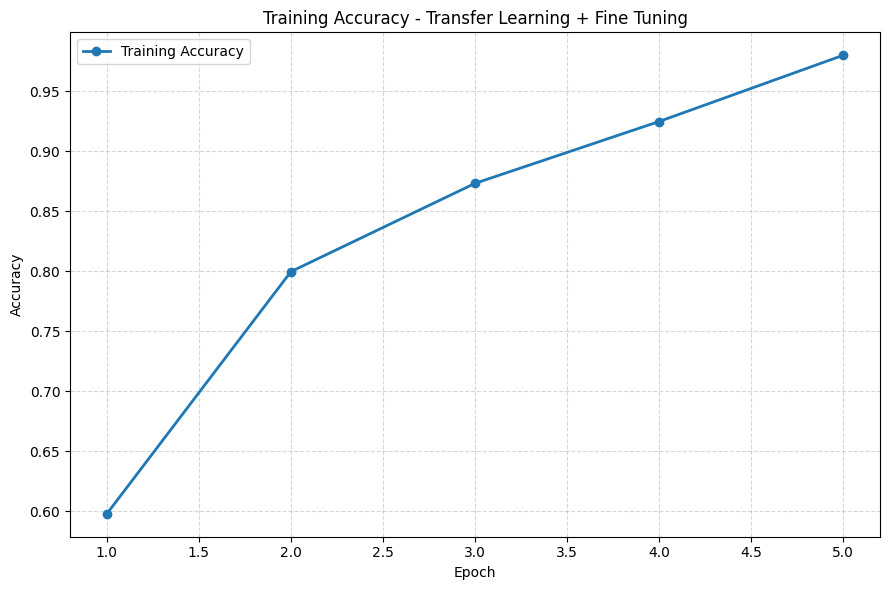

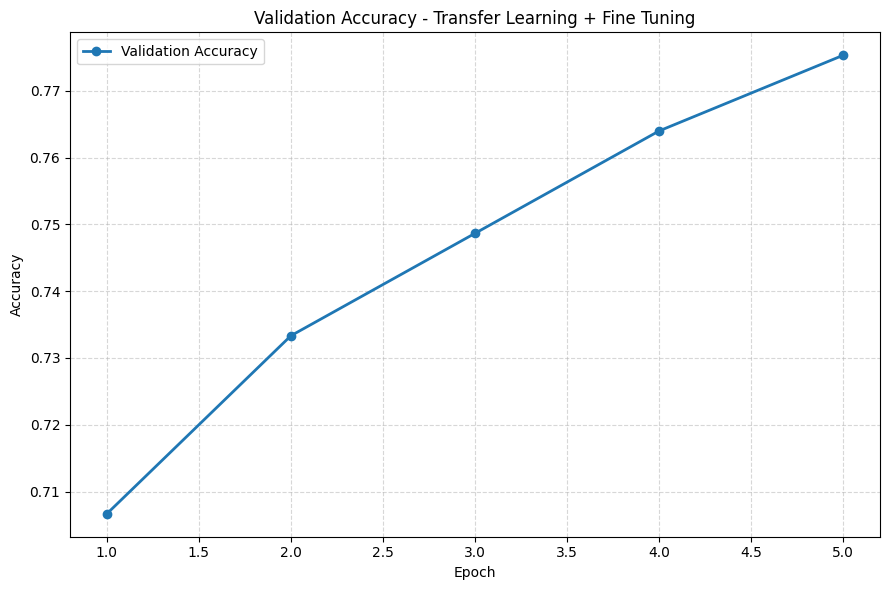

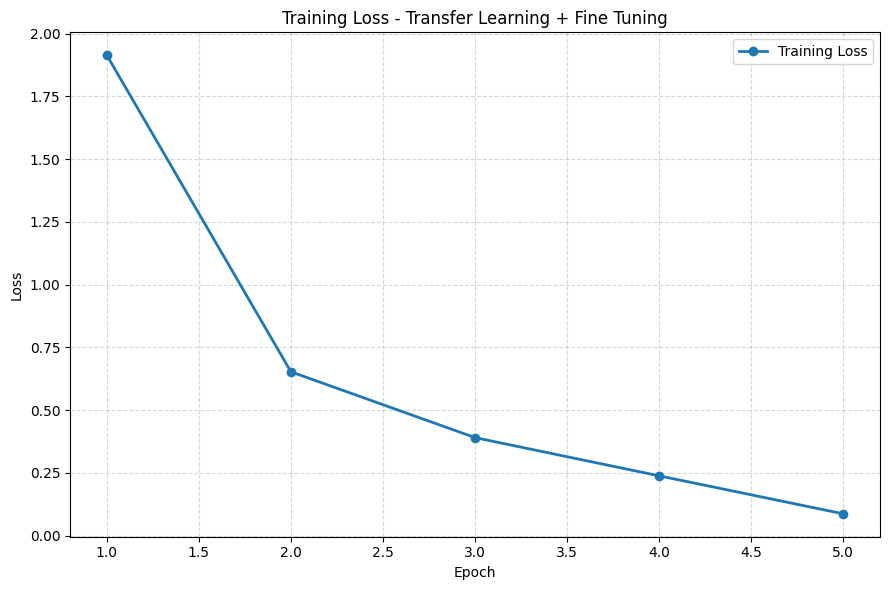

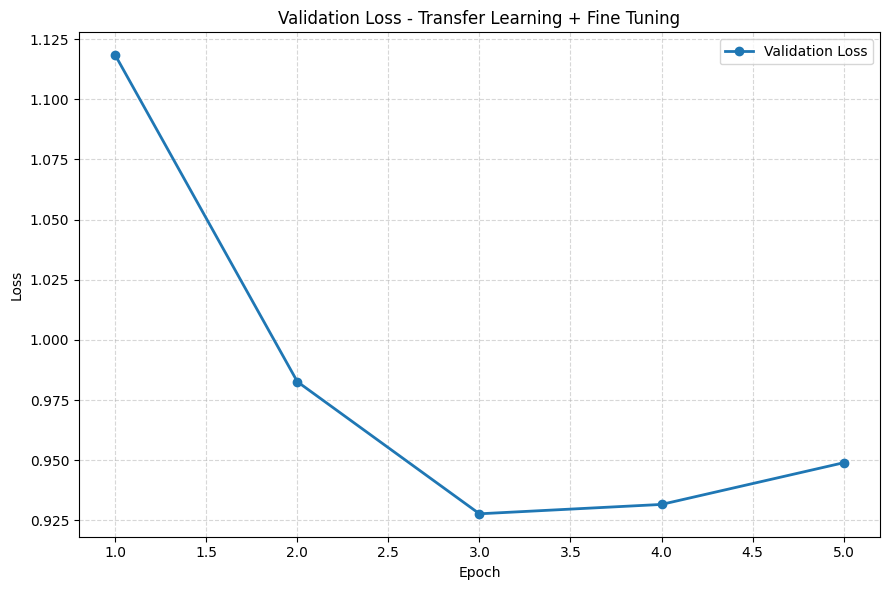

In [22]:
# ============================================================
# 24-27. FINAL COMBINED PLOTS (overwrite with full history)
# ============================================================

def plot_combined(x, values, ylabel, title, filename, marker_label):
    plt.figure(figsize=(9, 6))
    plt.plot(x, values, linewidth=2, marker="o", label=marker_label)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(RESULT_DIR, filename), format="eps", dpi=600, bbox_inches="tight")
    plt.show()
    plt.close()


plot_combined(total_epochs, all_train_accuracy, "Accuracy",
              "Training Accuracy - Transfer Learning + Fine Tuning",
              "02_training_accuracy.eps", "Training Accuracy")
plot_combined(total_epochs, all_val_accuracy, "Accuracy",
              "Validation Accuracy - Transfer Learning + Fine Tuning",
              "03_validation_accuracy.eps", "Validation Accuracy")
plot_combined(total_epochs, all_train_loss, "Loss",
              "Training Loss - Transfer Learning + Fine Tuning",
              "04_training_loss.eps", "Training Loss")
plot_combined(total_epochs, all_val_loss, "Loss",
              "Validation Loss - Transfer Learning + Fine Tuning",
              "05_validation_loss.eps", "Validation Loss")


In [23]:
# ============================================================
# 28. FINAL TEST EVALUATION
# ============================================================

print("\n")
print("=" * 70)
print("FINAL MODEL EVALUATION")
print("=" * 70)

test_loss, test_accuracy = model.evaluate(test_dataset, verbose=1)
print("\nFinal Test Accuracy:")
print("{:.4f}".format(test_accuracy))



FINAL MODEL EVALUATION
32/32 ━━━━━━━━━━━━━━━━━━━━ 214s 7s/step - accuracy: 0.7770 - loss: 0.9150

Final Test Accuracy:
0.7770


In [24]:
# ============================================================
# 29. GENERATE PREDICTIONS
# ============================================================

print("\nGenerating predictions...")

y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)


Generating predictions...


In [25]:
# ============================================================
# 30. CALCULATE METRICS
# ============================================================

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)



In [26]:
# ============================================================
# 31. PRINT PERFORMANCE METRICS
# ============================================================

print("\n")
print("=" * 70)
print("PERFORMANCE METRICS")
print("=" * 70)

print("Training Accuracy : {:.4f}".format(all_train_accuracy[-1]))
print("Testing Accuracy  : {:.4f}".format(accuracy))
print("Precision          : {:.4f}".format(precision))
print("Recall             : {:.4f}".format(recall))
print("F1-score           : {:.4f}".format(f1))
print("Training Time      : {:.2f} seconds".format(training_time + fine_tuning_time))
print("Total Parameters   : {}".format(model.count_params()))



PERFORMANCE METRICS
Training Accuracy : 0.9798
Testing Accuracy  : 0.7770
Precision          : 0.7783
Recall             : 0.7770
F1-score           : 0.7773
Training Time      : 4428.18 seconds
Total Parameters   : 14781642


In [27]:
# ============================================================
# 32. CLASSIFICATION REPORT
# ============================================================

report = classification_report(
    y_true, y_pred, target_names=CLASS_NAMES, digits=4, zero_division=0
)

print("\n")
print("=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)
print(report)

with open(os.path.join(RESULT_DIR, "classification_report.txt"), "w") as f:
    f.write(report)




CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Airplane     0.7800    0.7879    0.7839       198
  Automobile     0.8812    0.8641    0.8725       206
        Bird     0.7394    0.6881    0.7128       202
         Cat     0.5749    0.6198    0.5965       192
        Deer     0.7385    0.7630    0.7506       211
         Dog     0.7167    0.6789    0.6973       190
        Frog     0.8031    0.8289    0.8158       187
       Horse     0.8507    0.8221    0.8362       208
        Ship     0.8483    0.8606    0.8544       208
       Truck     0.8350    0.8434    0.8392       198

    accuracy                         0.7770      2000
   macro avg     0.7768    0.7757    0.7759      2000
weighted avg     0.7783    0.7770    0.7773      2000



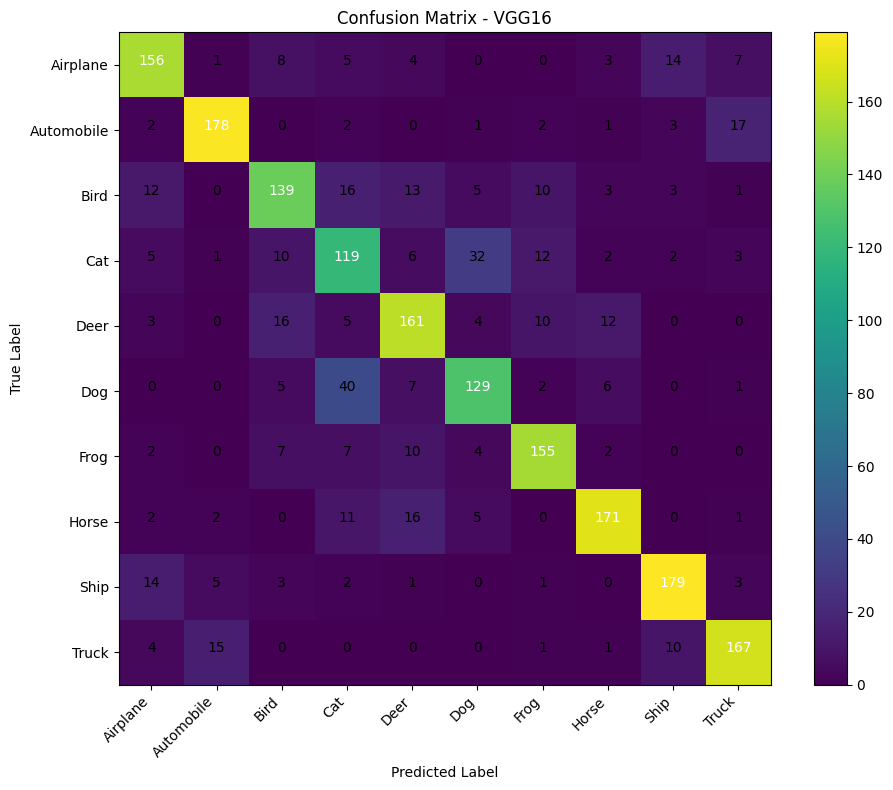

Saved: 06_confusion_matrix.eps


In [28]:
# ============================================================
# 33-34. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix - VGG16")
plt.colorbar()

tick_marks = np.arange(NUM_CLASSES)
plt.xticks(tick_marks, CLASS_NAMES, rotation=45, ha="right")
plt.yticks(tick_marks, CLASS_NAMES)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

threshold = cm.max() / 2.0
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(j, i, format(cm[i, j], "d"),
                  horizontalalignment="center",
                  color="white" if cm[i, j] > threshold else "black")

plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "06_confusion_matrix.eps"),
            format="eps", dpi=600, bbox_inches="tight")
plt.show()
plt.close()

print("Saved: 06_confusion_matrix.eps")



Finding misclassified images...


/tmp/ipykernel_661/4106546549.py:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  true_label = CLASS_NAMES[int(y_test_sub[idx])]


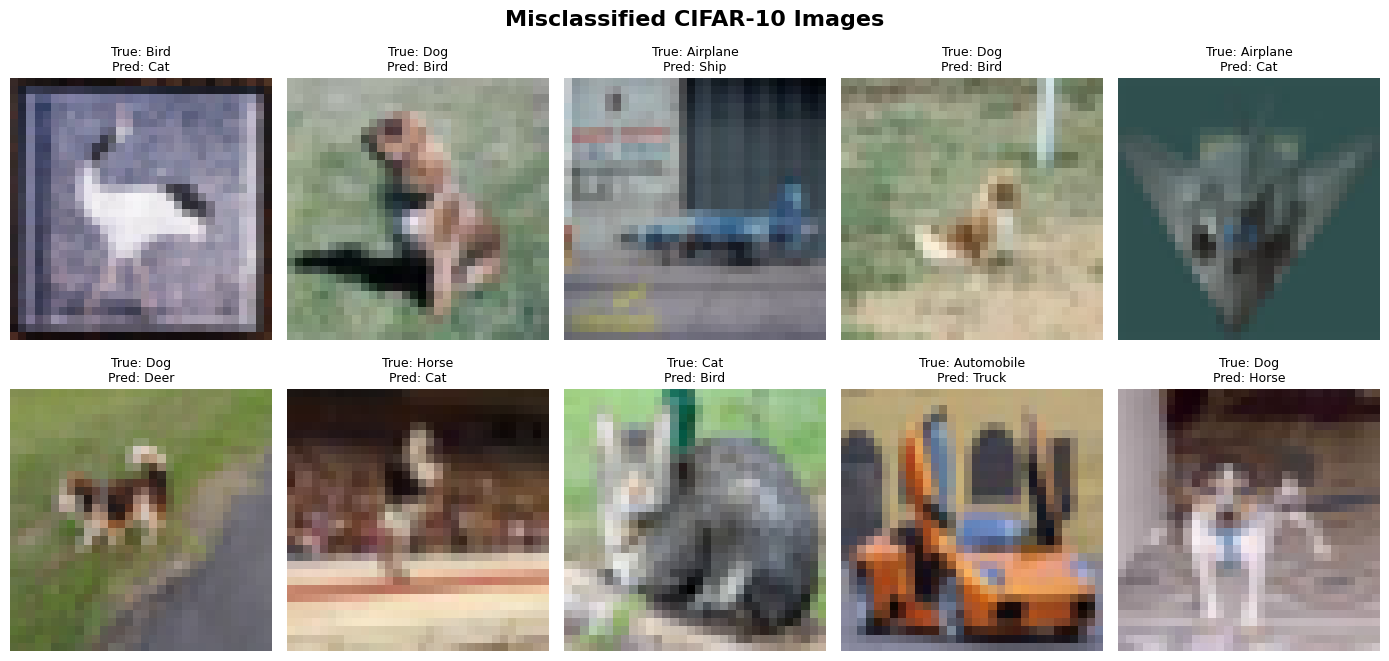

Saved: 07_misclassified_images.eps


In [29]:
# ============================================================
# 35. MISCLASSIFIED IMAGES
# ============================================================

print("\nFinding misclassified images...")

test_predictions = []

for start in range(0, len(x_test_sub), BATCH_SIZE):
    batch = x_test_sub[start:start + BATCH_SIZE]
    batch_processed = preprocess_dataset(batch)
    predictions = model.predict(batch_processed, verbose=0)
    test_predictions.extend(np.argmax(predictions, axis=1))

test_predictions = np.array(test_predictions)
misclassified_indices = np.where(test_predictions != y_test_sub.flatten())[0]

num_images = min(10, len(misclassified_indices))

if num_images > 0:
    plt.figure(figsize=(14, 7))
    for i in range(num_images):
        idx = misclassified_indices[i]
        plt.subplot(2, 5, i + 1)
        plt.imshow(x_test_sub[idx])
        true_label = CLASS_NAMES[int(y_test_sub[idx])]
        predicted_label = CLASS_NAMES[int(test_predictions[idx])]
        plt.title("True: {}\nPred: {}".format(true_label, predicted_label), fontsize=9)
        plt.axis("off")

    plt.suptitle("Misclassified CIFAR-10 Images", fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(RESULT_DIR, "07_misclassified_images.eps"),
                format="eps", dpi=600, bbox_inches="tight")
    plt.show()
    plt.close()
    print("Saved: 07_misclassified_images.eps")

In [30]:
# ============================================================
# 36. PERFORMANCE METRICS TABLE
# ============================================================

metrics_table = pd.DataFrame({
    "Metric": [
        "Training Accuracy", "Testing Accuracy", "Precision", "Recall",
        "F1-score", "Training Time (seconds)", "Total Parameters"
    ],
    "Value": [
        all_train_accuracy[-1], accuracy, precision, recall, f1,
        training_time + fine_tuning_time, model.count_params()
    ]
})

print("\n")
print("=" * 70)
print("PERFORMANCE METRICS TABLE")
print("=" * 70)
print(metrics_table.to_string(index=False))

metrics_table.to_csv(os.path.join(RESULT_DIR, "performance_metrics.csv"), index=False)



PERFORMANCE METRICS TABLE
                 Metric        Value
      Training Accuracy 9.798333e-01
       Testing Accuracy 7.770000e-01
              Precision 7.783056e-01
                 Recall 7.770000e-01
               F1-score 7.773476e-01
Training Time (seconds) 4.428179e+03
       Total Parameters 1.478164e+07


In [31]:
# ============================================================
# 37. CNN ARCHITECTURE COMPARISON
# ============================================================

architecture_comparison = pd.DataFrame({
    "Model": ["LeNet-5", "AlexNet", "VGG16", "GoogleNet", "ResNet50"],
    "Parameters": ["60K", "61M", "138M", "6.8M", "25.6M"],
    "Accuracy (%)": ["N/A", "N/A", accuracy * 100, "N/A", "N/A"],
    "Training Time": [
        "N/A", "N/A", "{:.2f} sec".format(training_time + fine_tuning_time), "N/A", "N/A"
    ]
})

print("\n")
print("=" * 70)
print("CNN ARCHITECTURE COMPARISON")
print("=" * 70)
print(architecture_comparison.to_string(index=False))

architecture_comparison.to_csv(os.path.join(RESULT_DIR, "model_comparison.csv"), index=False)




CNN ARCHITECTURE COMPARISON
    Model Parameters Accuracy (%) Training Time
  LeNet-5        60K          N/A           N/A
  AlexNet        61M          N/A           N/A
    VGG16       138M         77.7   4428.18 sec
GoogleNet       6.8M          N/A           N/A
 ResNet50      25.6M          N/A           N/A


In [32]:
# ============================================================
# 38. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("EXPERIMENT COMPLETED (FAST MODE)")
print("=" * 70)

print("\nSettings used:")
print("  Image size        :", IMAGE_SIZE, "x", IMAGE_SIZE)
print("  Train / Val / Test subset sizes :", TRAIN_SUBSET, "/", VAL_SUBSET, "/", TEST_SUBSET)
print("  Initial epochs     :", EPOCHS)
print("  Fine-tune epochs   :", FINE_TUNE_EPOCHS)

print("\nGenerated files:")
for file in sorted(os.listdir(RESULT_DIR)):
    print("  ->", file)

print("\nAll mandatory plots have been saved in EPS format.")
print("Resolution: 600 DPI")

print("\nFinal Test Accuracy:  {:.2f}%".format(accuracy * 100))
print("Precision: {:.4f}".format(precision))
print("Recall:    {:.4f}".format(recall))
print("F1 Score:  {:.4f}".format(f1))

print("\nDone!")



EXPERIMENT COMPLETED (FAST MODE)

Settings used:
  Image size        : 96 x 96
  Train / Val / Test subset sizes : 6000 / 1500 / 2000
  Initial epochs     : 3
  Fine-tune epochs   : 2

Generated files:
  -> 01_sample_cifar10.eps
  -> 02_training_accuracy.eps
  -> 03_validation_accuracy.eps
  -> 04_training_loss.eps
  -> 05_validation_loss.eps
  -> 06_confusion_matrix.eps
  -> 07_misclassified_images.eps
  -> classification_report.txt
  -> model_comparison.csv
  -> performance_metrics.csv

All mandatory plots have been saved in EPS format.
Resolution: 600 DPI

Final Test Accuracy:  77.70%
Precision: 0.7783
Recall:    0.7770
F1 Score:  0.7773

Done!
